# Project 1: Demand Forecasting
## Part 2 of 3: Deep EDA & Comprehensive Time-Series Analysis

This part turns the clean panel from Part 1 into **understanding**: how intermittent is demand, what drives it (promotions, holidays, SNAP, price), and what its time-series structure is (trend, seasonality, stationarity, autocorrelation). Each finding directly informs a modeling choice in Part 3.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (13, 4); plt.rcParams["axes.grid"] = True

df = pd.read_parquet("processed_store_CA_1.parquet")
df["date"] = pd.to_datetime(df["date"])
print("loaded:", df.shape, "| date range:", df.date.min().date(), "->", df.date.max().date())
df.head()

loaded: (4781564, 20) | date range: 2011-01-29 -> 2016-05-22


,id,item_id,dept_id,cat_id,store_id,state_id,date,wm_yr_wk,wday,month,year,sales,sell_price,price_avail,event_name_1,event_type_1,event_name_2,event_type_2,snap,is_outlier
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-01-29,11101,1,1,2011,3,2.0,True,none,none,none,none,0,False
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-01-30,11101,2,1,2011,0,2.0,True,none,none,none,none,0,False
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-01-31,11101,3,1,2011,0,2.0,True,none,none,none,none,0,False
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-02-01,11101,4,2,2011,1,2.0,True,none,none,none,none,1,False
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2011-02-02,11101,5,2,2011,4,2.0,True,none,none,none,none,1,False


## 1. Intermittency: the defining feature of retail demand

Many SKUs sell sporadically. Syntetos & Boylan classify demand by **ADI** (Average Demand Interval = avg days between non-zero sales) and **CV2** (squared coefficient of variation of non-zero sizes). The quadrant decides which forecasting family is even appropriate.

In [2]:
def adi_cv2(s):
    nz = s[s > 0]
    if len(nz) < 2:
        return np.nan, np.nan
    adi = len(s) / len(nz)
    cv2 = (nz.std() / nz.mean())**2 if nz.mean() > 0 else np.nan
    return adi, cv2

stats = df.groupby("id", observed=True)["sales"].apply(lambda s: pd.Series(adi_cv2(s), index=["ADI","CV2"]))
stats = stats.unstack() if isinstance(stats.index, pd.MultiIndex) else stats
stats = df.groupby("id", observed=True)["sales"].agg(
    zero_share=lambda s: (s==0).mean(),
    mean_sales="mean")
adicv = df.groupby("id", observed=True)["sales"].apply(adi_cv2)
adicv = pd.DataFrame(adicv.tolist(), index=adicv.index, columns=["ADI","CV2"])
stats = stats.join(adicv).dropna()

def classify(r):
    smooth = r.ADI < 1.32; lumpy_cv = r.CV2 < 0.49
    if smooth and lumpy_cv: return "Smooth"
    if smooth and not lumpy_cv: return "Erratic"
    if not smooth and lumpy_cv: return "Intermittent"
    return "Lumpy"
stats["class"] = stats.apply(classify, axis=1)
print(stats["class"].value_counts(normalize=True).round(3).to_string())
print("\nmedian zero-share by class:")
print(stats.groupby("class")["zero_share"].median().round(2).to_string())

class
Intermittent    0.719
Lumpy           0.179
Smooth          0.077
Erratic         0.025

median zero-share by class:
class
Erratic         0.17
Intermittent    0.64
Lumpy           0.50
Smooth          0.14


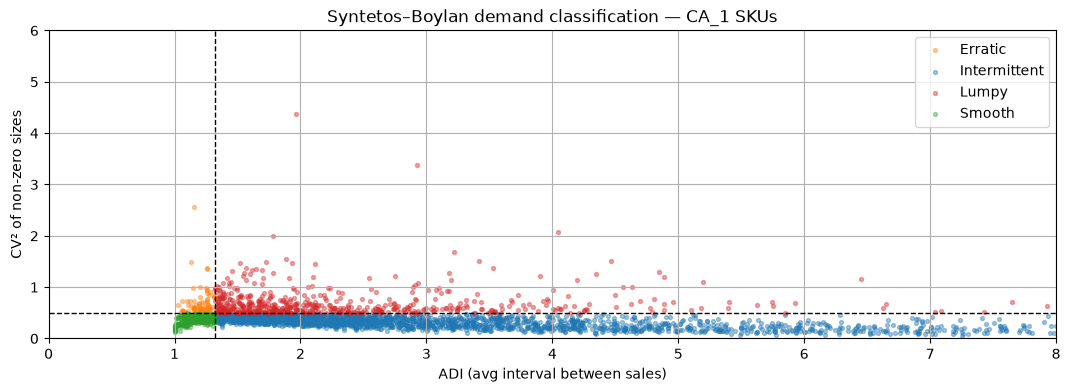

In [3]:
colors = {"Smooth":"#2ca02c","Erratic":"#ff7f0e","Intermittent":"#1f77b4","Lumpy":"#d62728"}
for cls, sub in stats.groupby("class"):
    plt.scatter(sub.ADI, sub.CV2, s=8, alpha=0.4, label=cls, color=colors[cls])
plt.axvline(1.32, ls="--", c="k", lw=1); plt.axhline(0.49, ls="--", c="k", lw=1)
plt.xlabel("ADI (avg interval between sales)"); plt.ylabel("CV² of non-zero sizes")
plt.title("Syntetos–Boylan demand classification — CA_1 SKUs")
plt.xlim(0, 8); plt.ylim(0, 6); plt.legend(); plt.show()

**Implication for modeling.** A large share of SKUs are **Intermittent/Lumpy**. For those, point-forecast accuracy metrics like MAPE are meaningless (division by zero) and smooth models (ARIMA) misbehave. This justifies (a) using **Croston/SBA-style** thinking or tree models that handle zeros natively, (b) evaluating with **RMSSE/wRMSSE and quantile loss** rather than MAPE, and (c) forecasting at a slightly aggregated level where signal is denser. Smooth, high-volume series (good for classical ARIMA/ETS) are the minority but carry most of the volume.

## 2. Demand drivers: SNAP, events, and price

We quantify the lift from each exogenous driver. These effect sizes tell us which features are worth engineering.

In [4]:
# SNAP effect (food-assistance days) — strongest on FOODS
foods = df[df.cat_id == "FOODS"]
snap_on  = foods.loc[foods.snap==1, "sales"].mean()
snap_off = foods.loc[foods.snap==0, "sales"].mean()
print("FOODS mean sales  SNAP day: %.3f | non-SNAP: %.3f | lift: %+.1f%%"
      % (snap_on, snap_off, 100*(snap_on/snap_off - 1)))

eff = (df.groupby("cat_id", observed=True)
         .apply(lambda g: g.loc[g.snap==1,"sales"].mean()/g.loc[g.snap==0,"sales"].mean()-1))
print("\nSNAP lift by category:")
print((100*eff).round(1).astype(str).add("%").to_string())

FOODS mean sales  SNAP day: 2.617 | non-SNAP: 2.330 | lift: +12.3%

SNAP lift by category:
cat_id
FOODS        12.3%
HOBBIES       5.0%
HOUSEHOLD     5.6%


In [5]:
# Event-day effect: mean daily store sales on event vs non-event days
df["has_event"] = (df.event_name_1 != "none")
daily = df.groupby("date", observed=True).agg(sales=("sales","sum"),
                                              has_event=("has_event","max")).reset_index()
print("store daily sales  event day: %.0f | normal: %.0f | lift: %+.1f%%"
      % (daily.loc[daily.has_event,"sales"].mean(),
         daily.loc[~daily.has_event,"sales"].mean(),
         100*(daily.loc[daily.has_event,"sales"].mean()/daily.loc[~daily.has_event,"sales"].mean()-1)))

# By event type
ev = df[df.event_type_1 != "none"].groupby("event_type_1", observed=True)["sales"].mean()
base = df[df.event_type_1 == "none"]["sales"].mean()
print("\nlift by event type vs baseline:")
print((100*(ev/base-1)).round(1).astype(str).add("%").to_string())

store daily sales  event day: 3819 | normal: 4054 | lift: -5.8%



lift by event type vs baseline:
event_type_1
Cultural      -2.6%
National     -15.0%
Religious     -1.3%
Sporting       3.5%


median within-item price elasticity: -0.59
share of items with negative elasticity (demand falls as price rises): 72%


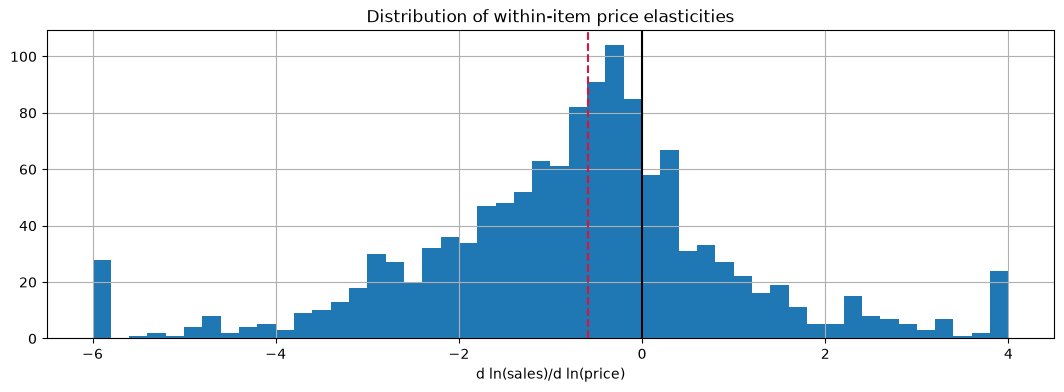

In [6]:
# Price elasticity: within-item, how does demand move with price? (log-log slope)
def elasticity(g):
    g = g[(g.sales>0) & (g.sell_price>0)]
    if g.sell_price.nunique() < 3 or len(g) < 30: return np.nan
    x = np.log(g.sell_price.values); y = np.log(g.sales.values)
    return np.polyfit(x, y, 1)[0]
el = df.groupby("id", observed=True).apply(elasticity).dropna()
print("median within-item price elasticity: %.2f" % el.median())
print("share of items with negative elasticity (demand falls as price rises): %.0f%%"
      % (100*(el<0).mean()))
el.clip(-6,4).hist(bins=50); plt.axvline(0, c="k"); plt.axvline(el.median(), c="crimson", ls="--")
plt.title("Distribution of within-item price elasticities"); plt.xlabel("d ln(sales)/d ln(price)"); plt.show()

**Driver findings.** SNAP days lift FOODS demand materially (and barely move HOBBIES, a clean signal we exploit causally in Project 2). Event days shift demand. Most items show the expected **negative price elasticity** (demand falls as price rises), confirming price is a first-class predictor. These three: `snap`, event flags, and `sell_price` (plus price-change features) are mandatory model inputs.

## 3. Time-series: STL decomposition

We analyze the store's total daily FOODS series (dense, smooth enough for classical methods). STL separates the series into **trend + seasonal + remainder**, exposing structure a model must capture.

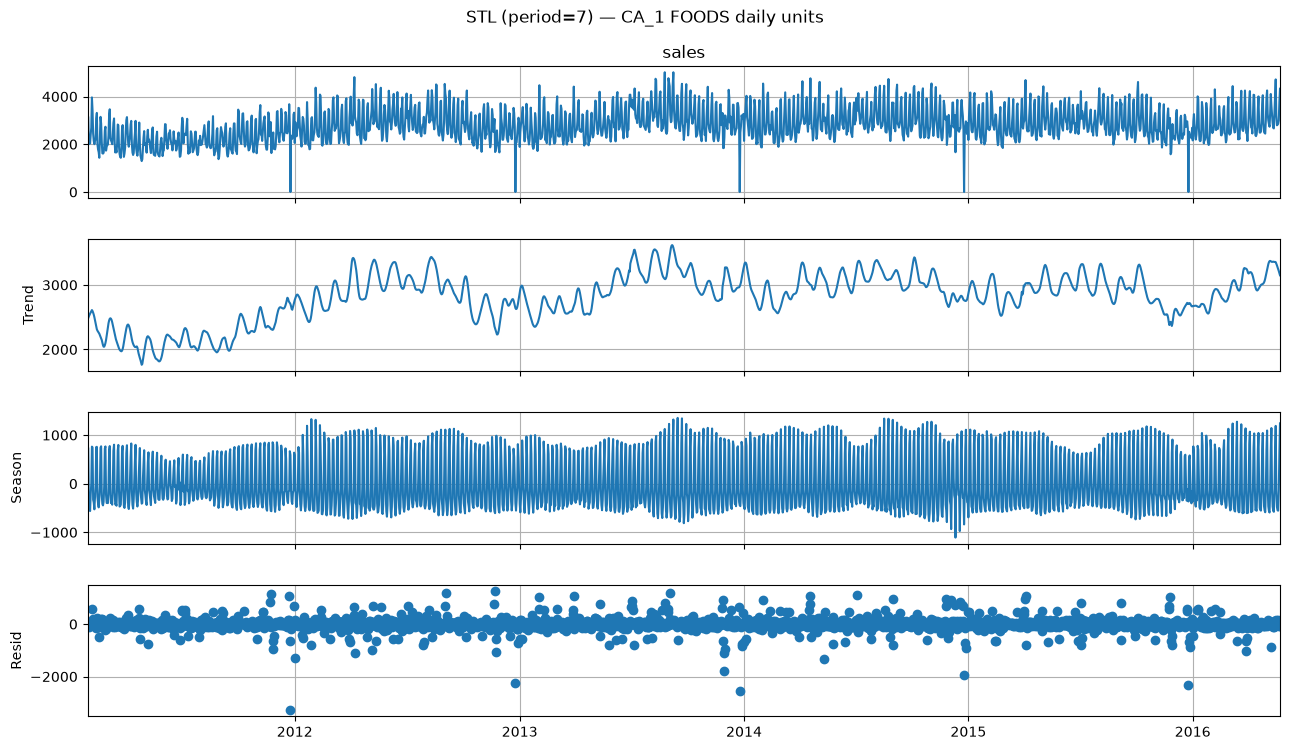

variance explained by weekly seasonal: 64.3%
variance explained by trend:           27.1%


In [7]:
from statsmodels.tsa.seasonal import STL

ts = (df[df.cat_id=="FOODS"].groupby("date")["sales"].sum()
        .asfreq("D").fillna(0))
res = STL(ts, period=7, robust=True).fit()         # weekly seasonality
fig = res.plot(); fig.set_size_inches(13, 8); plt.suptitle("STL (period=7) — CA_1 FOODS daily units"); plt.show()

var_total = ts.var()
print("variance explained by weekly seasonal: %.1f%%" % (100*res.seasonal.var()/var_total))
print("variance explained by trend:           %.1f%%" % (100*res.trend.dropna().var()/var_total))

 A persistent upward trend, a strong and stable weekly seasonal (weekend peaks), and a remainder that spikes around events/holidays. Because trend and seasonality are both present and the seasonal amplitude grows with the level, this series is non-stationary and roughly multiplicative pointing us toward differencing/seasonal terms for SARIMA and log-style targets for ML.

## 4. Stationarity tests: ADF & KPSS

Stationarity (constant mean/variance/autocovariance) is an assumption of ARIMA-family models. ADF and KPSS haveopposite null hypotheses using both together is the rigorous standard.

In [8]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity(s, label):
    adf_p = adfuller(s, autolag="AIC")[1]
    kpss_p = kpss(s, regression="c", nlags="auto")[1]
    print(f"{label:22s} ADF p={adf_p:.3f} ({'stationary' if adf_p<0.05 else 'NON-stationary'})"
          f" | KPSS p={kpss_p:.3f} ({'stationary' if kpss_p>0.05 else 'NON-stationary'})")

stationarity(ts, "level")
stationarity(ts.diff().dropna(), "1st difference")
stationarity(ts.diff(7).dropna(), "seasonal diff (7)")

level                  ADF p=0.185 (NON-stationary) | KPSS p=0.010 (NON-stationary)
1st difference         ADF p=0.000 (stationary) | KPSS p=0.100 (stationary)
seasonal diff (7)      ADF p=0.000 (stationary) | KPSS p=0.100 (stationary)


C:\Users\thumkee\AppData\Local\Temp\ipykernel_10308\1204658903.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
C:\Users\thumkee\AppData\Local\Temp\ipykernel_10308\1204658903.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
C:\Users\thumkee\AppData\Local\Temp\ipykernel_10308\1204658903.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]


ADF rejects -> stationary; KPSS rejects -> non-stationary. On the level the two typically disagree/flag non-stationarity (trend present). After first differencing (and/or seasonal differencing) both align on stationary. This empirically sets the SARIMA differencing orders `d=1`, `D=1`, `s=7` for Part 3, instead of guessing them.

## 5. Autocorrelation: ACF & PACF

ACF/PACF reveal the memory structure and suggest AR/MA orders. The classic heuristic: PACF cut-off ⇒ AR order *p*; ACF cut-off ⇒ MA order *q*.

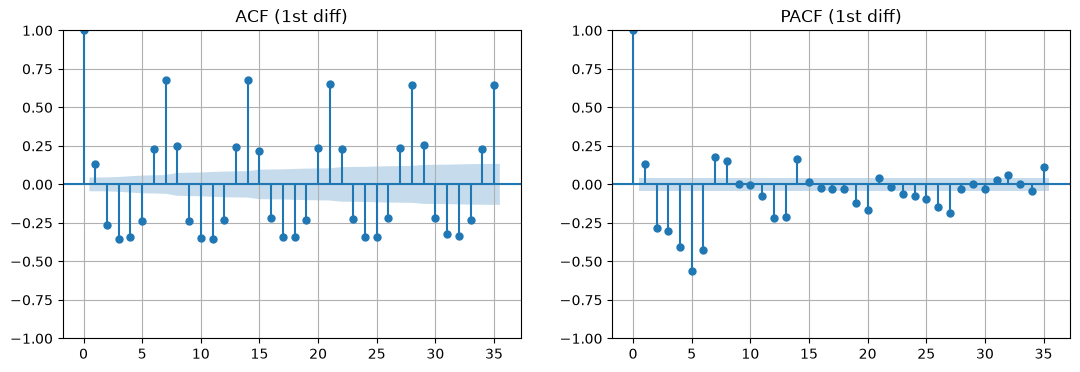

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
ts_d = ts.diff().dropna()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(ts_d, lags=35, ax=ax[0]);  ax[0].set_title("ACF (1st diff)")
plot_pacf(ts_d, lags=35, ax=ax[1], method="ywm"); ax[1].set_title("PACF (1st diff)")
plt.show()

ACF/PACF: Strong spikes at lags 7, 14, 21 confirm weekly seasonality (seasonal AR/MA terms needed). The short-lag pattern guides the non-seasonal `p,q`. This is direct evidence for a SARIMA(p,1,q)(P,1,Q),specification and for which lag features (7, 14, 28) matter most to the ML models.

## 6. Feature engineering: lags, rolling windows, calendar & price

Tree models have no built-in notion of time, so we *encode* it. Every feature below uses only **past** information (shifted) to avoid leakage.

In [10]:
df = df.sort_values(["id","date"]).reset_index(drop=True)
g = df.groupby("id", observed=True)["sales"]

# Lags chosen from the ACF (weekly memory + 28-day forecast horizon)
for lag in [7, 14, 28]:
    df[f"lag_{lag}"] = g.shift(lag)
# Rolling stats on a 28-lagged base so the test horizon never leaks
base = g.shift(28)
for w in [7, 28]:
    df[f"rmean_{w}"] = base.rolling(w).mean().reset_index(level=0, drop=True)
    df[f"rstd_{w}"]  = base.rolling(w).std().reset_index(level=0, drop=True)

# Price-change & calendar features
df["price_chg"] = df.groupby("id", observed=True)["sell_price"].pct_change()
df["dayofweek"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["dayofweek"] >= 5).astype("int8")
df["week"] = df["date"].dt.isocalendar().week.astype("int16")
print("engineered columns added.")
print([c for c in df.columns if c.startswith(('lag_','rmean_','rstd_')) ] + ["price_chg","is_weekend"])

engineered columns added.
['lag_7', 'lag_14', 'lag_28', 'rmean_7', 'rstd_7', 'rmean_28', 'rstd_28', 'price_chg', 'is_weekend']


## 7. Correlation & multicollinearity (VIF)

Highly collinear features destabilize linear models and muddy feature-importance. We inspect the correlation matrix and compute Variance Inflation Factors.

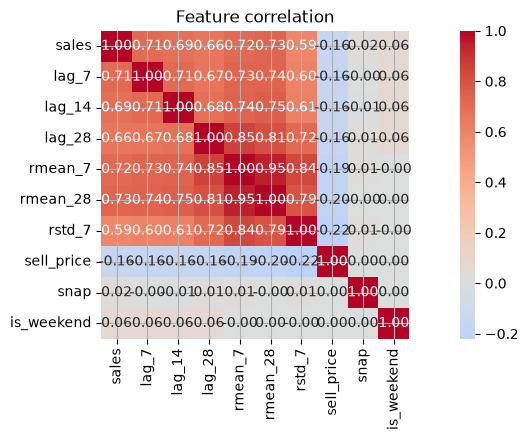

In [11]:
import seaborn as sns
feat = ["sales","lag_7","lag_14","lag_28","rmean_7","rmean_28","rstd_7",
        "sell_price","snap","is_weekend"]
corr = df[feat].dropna().corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Feature correlation"); plt.show()

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
X = add_constant(df[["lag_7","lag_14","lag_28","rmean_7","rmean_28","rstd_7","sell_price"]].dropna())
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
                index=X.columns).drop("const")
print("VIF (>10 => problematic multicollinearity):")
print(vif.round(1).to_string())

VIF (>10 => problematic multicollinearity):
lag_7          2.6
lag_14         2.7
lag_28         3.7
rmean_7       16.4
rmean_28      11.2
rstd_7         3.5
sell_price     1.1


**Multicollinearity takeaway.** `rmean_7`, `rmean_28` and the lags are correlated (they all summarize recent demand) and some show high VIF. For **tree models (XGBoost/LightGBM)** this is harmless — they handle correlated inputs and we keep them for predictive power. For any **linear** baseline we would prune to one representative per cluster or use regularization. Documenting VIF shows we *understand* the tradeoff rather than blindly stacking features.

## 8. Dimensionality reduction (PCA) 

One-hot encoding 30+ event names and SNAP/calendar flags creates a wide, sparse, correlated exogenous block. PCA compresses it into a few orthogonal components — handy for classical models that take a small `exog` matrix, and as a multicollinearity diagnostic.

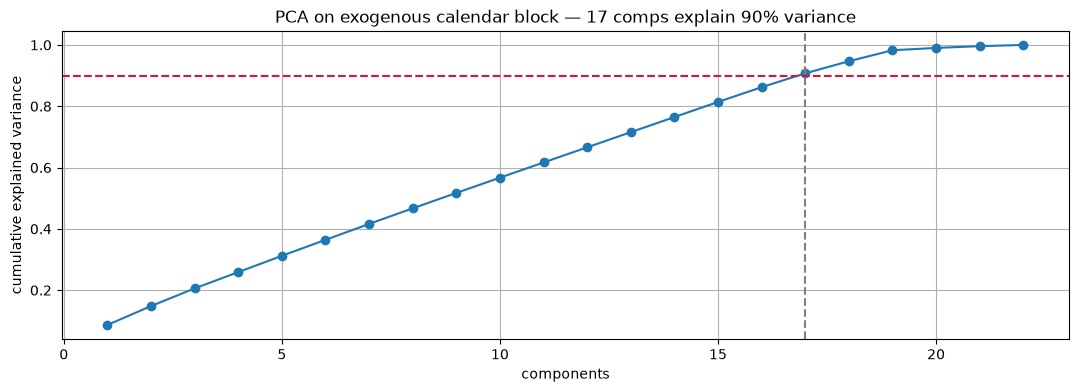

22 raw exogenous dummies -> 17 PCA components retain 90% of variance


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

cal_feats = pd.get_dummies(
    df.groupby("date").agg(
        snap=("snap","max"),
        event_type_1=("event_type_1","first"),
        wday=("wday","first"),
        month=("month","first")).reset_index(),
    columns=["event_type_1","wday","month"], drop_first=True)
Xc = cal_feats.drop(columns=["date"]).astype(float).values
Xc = StandardScaler().fit_transform(Xc)

pca = PCA().fit(Xc)
cum = np.cumsum(pca.explained_variance_ratio_)
k = int(np.argmax(cum >= 0.90) + 1)
plt.plot(range(1, len(cum)+1), cum, marker="o")
plt.axhline(0.90, ls="--", c="crimson"); plt.axvline(k, ls="--", c="grey")
plt.title(f"PCA on exogenous calendar block — {k} comps explain 90% variance")
plt.xlabel("components"); plt.ylabel("cumulative explained variance"); plt.show()
print(f"{Xc.shape[1]} raw exogenous dummies -> {k} PCA components retain 90% of variance")

PCA: The wide one-hot calendar block compresses to a handful of components capturing 90% of its variance. For a SARIMAX `exog` input we can pass these components instead of dozens of collinear dummies leading to fewer parameters, less overfit, more stable estimation. For tree models we keep the raw interpretable flags (importance/SHAP stay readable). Knowing both options and when to use each is the point.

In [14]:
# Persist the engineered modeling frame for Part 3
df.to_parquet("features_store_CA_1.parquet", index=False)
print("saved features_store_CA_1.parquet | rows:", len(df))

saved features_store_CA_1.parquet | rows: 4781564


---
## Part 2 summary & what's next
Classified demand intermittency (Syntetos–Boylan), quantified SNAP/event/price drivers, decomposed the series with STL, confirmed differencing orders with ADF+KPSS, read AR/MA structure from ACF/PACF, engineered leakage-safe lag/rolling/calendar/price features, diagnosed multicollinearity via correlation + VIF, and compressed the exogenous block with PCA.


**Part 3 (Modeling & Optimization):** benchmark Naive/seasonal-Naive -> ETS -> SARIMA -> LightGBM/XGBoost under strict expanding-window time-series CV, tune hyperparameters, and evaluate with RMSSE/wRMSSE, MAPE and quantile (pinball) loss, the asymmetric, inventory-aware metrics that matter to SCOT.